In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import MultipleLocator, FixedLocator
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from utils import load_VAE_data, compute_features, compute_features_v2
from figs_utils import plot_detection_results, load_v_data

import gzip, bz2, lzma, joblib
import traceback

import numpy as np
import matplotlib.pyplot as plt


In [2]:
path = "/Users/kiki/school/whole/results/1021_2/test_results_dict.pkl"
results_dict = pickle.load(open(path, "rb"))

In [3]:
window = 100
features = ['VRTG', 'VRTG_diff_1', 'VRTG_diff_10', 'VRTG_z']

# data
train_data, val_data, test_data = load_VAE_data('data')

train_flight_ids = train_data['flight_id'].values
val_flight_ids = val_data['flight_id'].values
test_flight_ids = test_data['flight_id'].values

train_data = compute_features_v2(train_data, rolling_window_size=window)
val_data = compute_features_v2(val_data, rolling_window_size=window)
test_data = compute_features_v2(test_data, rolling_window_size=window)

X_train, y_train = train_data[features].values, (train_data['status'] == 'abnormal').astype(int).values
X_val, y_val = val_data[features].values, (val_data['status'] == 'abnormal').astype(int).values
X_test, y_test = test_data[features].values, (test_data['status'] == 'abnormal').astype(int).values

train_flight_ids:  [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57] length:  18
val_flight_ids: [98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112] length:  15
test_flight_ids: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 33, 34, 35, 36, 37, 38, 39, 58, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133] length:  86
Train size: 1539601, Val size: 1337017, Test size: 7079038


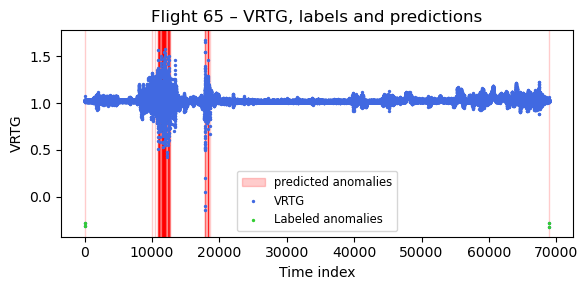

In [44]:
flight_id = 65

target_data = test_data[test_data['flight_id'] == flight_id]
target_data.index = range(len(target_data))

# 1. 取出该航段的数据
flight_data = (
    target_data[target_data['flight_id'] == flight_id]
    .sort_values('index')
    .reset_index(drop=True)
)

x = flight_data['index'].values
vrtg = flight_data['VRTG'].values

# 假设 status == 'abnormal' 是异常
label_abnormal = (flight_data['status'] == 'abnormal').values

# 2. 取出 BiLSTM 的预测结果
probas_raw = np.asarray(results_dict[flight_id]['probabilities'])
preds_raw  = np.asarray(results_dict[flight_id]['predictions'])

# ---- 核心修正 ①：把 probabilities 变成一维的“异常概率”向量 ----
# 情况1：已经是一维 (T,)
if probas_raw.ndim == 1:
    probas = probas_raw

# 情况2：二维 (T, num_classes)，典型是二分类 (T, 2)
elif probas_raw.ndim == 2:
    # 假设第1列是“异常”类别概率 [p_normal, p_abnormal]
    # 如果你那边的顺序不一样，就把 1 换成对应的列索引
    probas = probas_raw[:, 1]
else:
    raise ValueError(f"Unsupported probas shape: {probas_raw.shape}")

# 同理，把 preds 也处理成一维
if preds_raw.ndim == 1:
    preds = preds_raw
elif preds_raw.ndim == 2:
    # 如果是 one-hot 或 logits，取 argmax 作为预测类别
    preds = preds_raw.argmax(axis=-1)
else:
    raise ValueError(f"Unsupported preds shape: {preds_raw.shape}")

# 对齐长度
T = min(len(flight_data), len(probas), len(preds))
x = x[:T]
vrtg = vrtg[:T]
label_abnormal = label_abnormal[:T]
probas = probas[:T]
preds = preds[:T]

# ---- 核心修正 ②：保证 mask 是 1D 布尔向量 ----
threshold = 0.5
pred_mask = (probas > threshold).astype(bool).ravel()
# 或者用 preds == 1：
# pred_mask = (preds == 1)

def get_contiguous_segments(mask):
    """
    mask: 一维 bool 数组，True 表示预测为异常
    返回 [(start_idx, end_idx), ...]
    """
    mask = np.asarray(mask).astype(bool).ravel()  # 再保险 flatten 一下
    segments = []
    start = None
    for i, v in enumerate(mask):
        if v and start is None:
            start = i
        elif (not v) and (start is not None):
            segments.append((start, i - 1))
            start = None
    if start is not None:
        segments.append((start, len(mask) - 1))
    return segments

segments = get_contiguous_segments(pred_mask)

# 4. 画图
fig, ax = plt.subplots(figsize=(6, 3))

# 红色阴影：BiLSTM 预测异常区间
y_min, y_max = vrtg.min(), vrtg.max()
for idx, (s_idx, e_idx) in enumerate(segments):
    ax.axvspan(x[s_idx], x[e_idx],
               color='red',
               alpha=0.2,
               label='predicted anomalies' if idx == 0 else None)

# 蓝点：全体 VRTG
ax.scatter(x, vrtg, s=2, color='royalblue', label='VRTG')

# 绿点：人工标注异常
ax.scatter(x[label_abnormal],
           vrtg[label_abnormal],
           s=2,
           color='limegreen',
           label='Labeled anomalies')



ax.set_xlabel('Time index')
ax.set_ylabel('VRTG')
ax.set_title(f'Flight {flight_id} – VRTG, labels and predictions')
ax.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()
